In [18]:
import numpy as np 
import pandas as pd
from sklearn.datasets import load_diabetes

data = load_diabetes()
X = data.data
y = data.target

x = X[:,2]
m = x.shape[0]

print("m =", m)
print("x range:", x.min(), x.max())
print("y range:", y.min(), y.max())

m = 442
x range: -0.09027529589850945 0.17055522598064407
y range: 25.0 346.0


In [19]:
def f_wb(x, w, b):
    return w * x + b

In [20]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    y_hat = f_wb(x, w, b)
    err = y_hat - y
    J = (1 / (2*m)) * np.sum(err ** 2)
    return J

In [21]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f = w * x[i] + b
        err = f - y[i]
        dj_dw += err *  x[i]
        dj_db += err 

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [22]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    w = w_in
    b = b_in
    J_history = []

    for it in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        J = compute_cost(x, y, w, b)
        J_history.append(J)

        if it % 100 == 0:
            print(f"iter {it:4d}: J={J:.2f}, w={w:.4f}, b={b:.4f}")

    return w, b, J_history


In [32]:
w0 = 0
b0 = 0
alpha = 0.9
num_iters = 1000

w_gd, b_gd, J_hist = gradient_descent(x, y, w0, b0, alpha, num_iters)
print("Final w, b:", w_gd, b_gd)
print("Final cost:", J_hist[-1])


iter    0: J=3076.52, w=1.9332, b=136.9201
iter  100: J=2620.79, w=176.6497, b=152.1335
iter  200: J=2394.62, w=319.1490, b=152.1335
iter  300: J=2244.17, w=435.3719, b=152.1335
iter  400: J=2144.08, w=530.1636, b=152.1335
iter  500: J=2077.51, w=607.4760, b=152.1335
iter  600: J=2033.22, w=670.5322, b=152.1335
iter  700: J=2003.76, w=721.9611, b=152.1335
iter  800: J=1984.17, w=763.9067, b=152.1335
iter  900: J=1971.13, w=798.1176, b=152.1335
Final w, b: 825.7682716475864 152.1334841628961
Final cost: 1962.5286593631495


In [33]:
for alpha in [0.01, 0.1]:
    print("\nalpha =", alpha)
    w_gd, b_gd, J_hist = gradient_descent(x, y, 0, 0, alpha, 300)
    print("final J =", J_hist[-1])



alpha = 0.01
iter    0: J=14306.91, w=0.0215, b=1.5213
iter  100: J=4479.89, w=2.1671, b=97.0046
iter  200: J=3159.31, w=4.3078, b=131.9545
final J = 2979.0250341883557

alpha = 0.1
iter    0: J=12338.04, w=0.2148, b=15.2133
iter  100: J=2919.38, w=21.4516, b=152.1298
iter  200: J=2876.28, w=42.2133, b=152.1335
final J = 2835.4901694196396


iter    0: J=12338.04, w=0.2148, b=15.2133
iter  100: J=2919.38, w=21.4516, b=152.1298
iter  200: J=2876.28, w=42.2133, b=152.1335
iter  300: J=2835.09, w=62.5106, b=152.1335
iter  400: J=2795.72, w=82.3537, b=152.1335
iter  500: J=2758.09, w=101.7528, b=152.1335
iter  600: J=2722.12, w=120.7179, b=152.1335
iter  700: J=2687.75, w=139.2588, b=152.1335
iter  800: J=2654.89, w=157.3848, b=152.1335
iter  900: J=2623.49, w=175.1053, b=152.1335


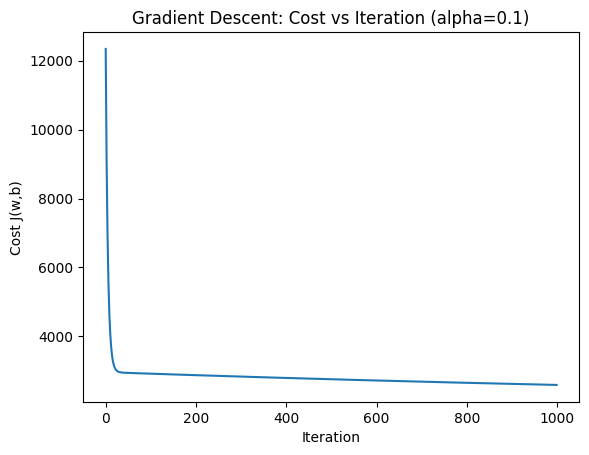

In [35]:
import matplotlib.pyplot as plt
# Cost history'i tekrar üretelim (emin olmak için)
w_gd, b_gd, J_hist = gradient_descent(x, y, 0, 0, alpha=0.1, num_iters=1000)

plt.plot(J_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Gradient Descent: Cost vs Iteration (alpha=0.1)")
plt.show()
